In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, pointbiserialr, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

In [4]:
processed_data = pd.read_csv("data.csv")
processed_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,churn
0,79,US-2014-147606,2014-11-26,2014-12-01,Second Class,JE-15745,Joel Eaton,Consumer,United States,Houston,...,5,0.6,-14.4750,0,97.0400,1.2130,316.092000,-42.551067,0,0
1,178,US-2015-101511,2015-11-21,2015-11-23,Second Class,JE-15745,Joel Eaton,Consumer,United States,Newark,...,7,0.3,-11.3372,360,19.3000,-14.4750,171.047333,-8.199733,12,0
2,235,US-2017-100930,2017-04-07,2017-04-12,Standard Class,CS-12400,Christopher Schild,Home Office,United States,Tampa,...,3,0.2,0.0000,0,620.6145,-248.2458,370.848833,-116.764600,0,1
3,242,CA-2016-157749,2016-06-04,2016-06-09,Second Class,KL-16645,Ken Lonsdale,Consumer,United States,Chicago,...,5,0.5,-120.5130,680,11.6880,-4.6752,202.864333,-160.638733,23,1
4,243,CA-2016-157749,2016-06-04,2016-06-09,Second Class,KL-16645,Ken Lonsdale,Consumer,United States,Chicago,...,3,0.6,-2.8308,680,177.2250,-120.5130,64.319000,-42.673000,23,1


## Reason for drop
Identifiers: These don't provide predictive power and should be dropped: Row ID, Order ID, Customer ID, Product ID

Text-based Identifiers: These columns are descriptive rather than predictive: Customer Name, Product Name

Columns Redundant for Churn Prediction: Depending on your dataset, certain columns might add noise rather than useful information for predicting churn: Order Date, Ship Date, Country, City, State, Postal Code, Region

In [7]:
columns_to_drop = ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 
                   'Customer ID', 'Customer Name', 'Product ID', 
                   'Product Name', 'Postal Code', 'City', 'State', 'Region', 
                  'Country']

In [8]:
modified = processed_data

In [9]:
modified_data = modified.drop(columns=columns_to_drop, axis = 1)

In [11]:
modified_data.head()

,Ship Mode,Segment,Category,Sub-Category,Sales,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,churn
0,Second Class,Consumer,Furniture,Furnishings,19.300,5,0.6,-14.4750,0,97.0400,1.2130,316.092000,-42.551067,0,0
1,Second Class,Consumer,Furniture,Chairs,396.802,7,0.3,-11.3372,360,19.3000,-14.4750,171.047333,-8.199733,12,0
2,Standard Class,Home Office,Furniture,Furnishings,258.072,3,0.2,0.0000,0,620.6145,-248.2458,370.848833,-116.764600,0,1
3,Second Class,Consumer,Furniture,Tables,177.225,5,0.5,-120.5130,680,11.6880,-4.6752,202.864333,-160.638733,23,1
4,Second Class,Consumer,Furniture,Furnishings,4.044,3,0.6,-2.8308,680,177.2250,-120.5130,64.319000,-42.673000,23,1


## Check for correlation

### Numerical data

In [22]:
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Days Since First Order', 'lag_sales_1', 'lag_profit_1', 'rolling_sales_mean_3', 'rolling_profit_mean_3']
numerical_corr = modified_data[numerical_cols].corr(method='pearson')

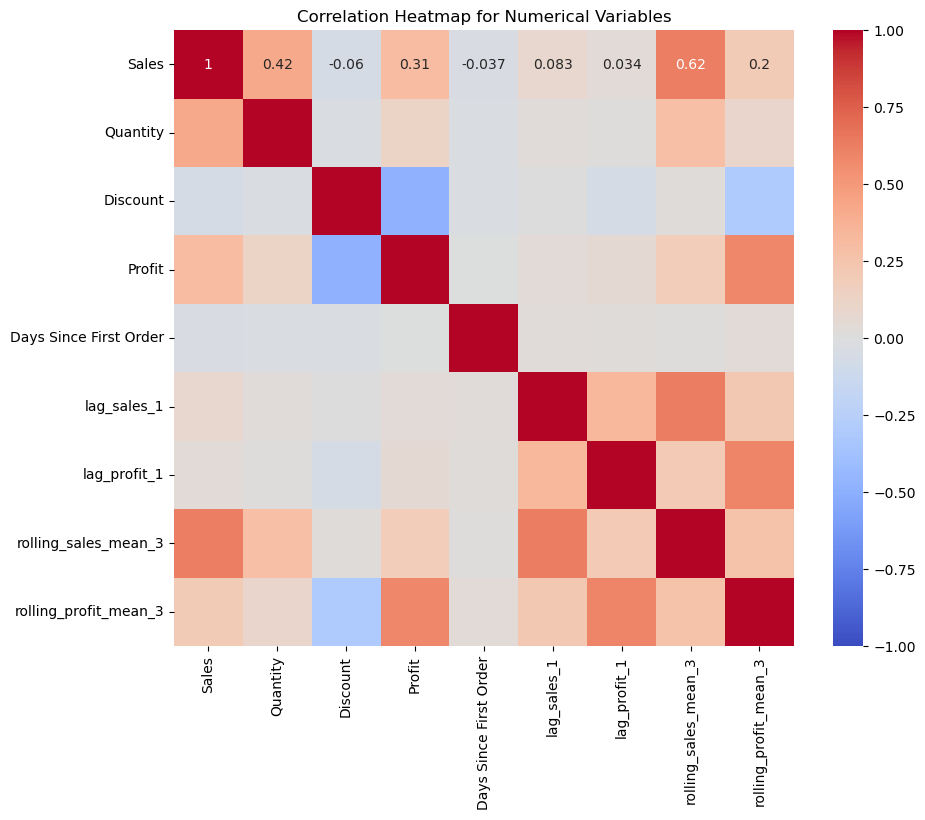

In [23]:
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap for Numerical Variables")
plt.show()

### Categorical data

In [24]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

In [25]:
categorical_cols = ['Segment', 'Ship Mode', 'Category', 'Sub-Category', 'cohort']
cramers_v_results = {col: cramers_v(modified_data[col], modified_data['churn']) for col in categorical_cols}

C:\Users\Kagui\AppData\Local\Temp\ipykernel_24520\1996664717.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))


C:\Users\Kagui\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


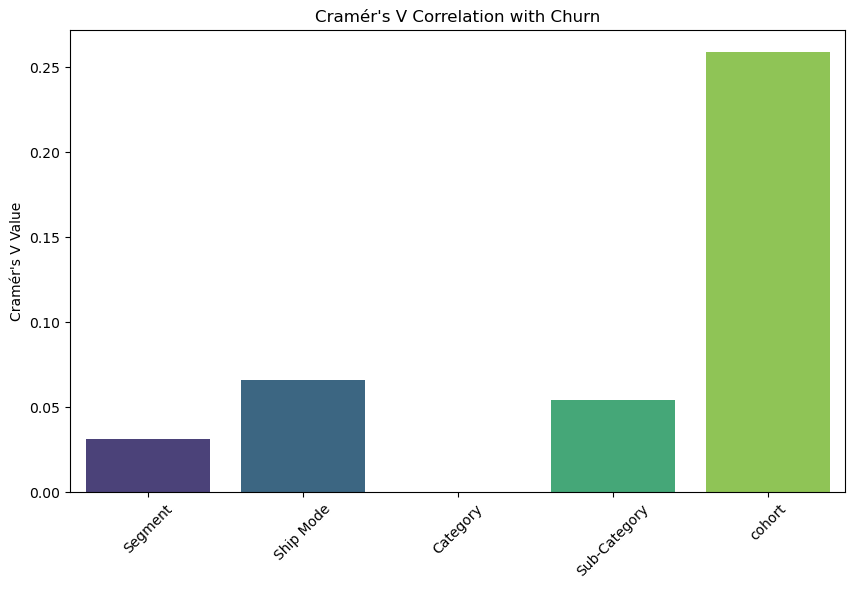

In [29]:
cramers_v_values = list(cramers_v_results.values())
cramers_v_labels = list(cramers_v_results.keys( ))

plt.figure(figsize=(10, 6))
sns.barplot(x=cramers_v_labels, y=cramers_v_values, palette="viridis")
plt.ylabel("Cramér's V Value")
plt.title("Cramér's V Correlation with Churn")
plt.xticks(rotation=45)
plt.show()

### check for normal distribuation

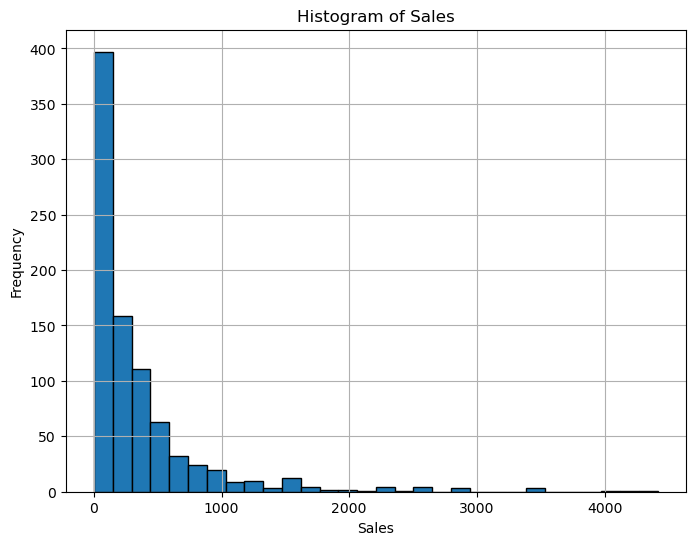

In [33]:
##Only one column
plt.figure(figsize=(8, 6))
modified_data['Sales'].hist(bins=30, edgecolor='black')
plt.title('Histogram of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

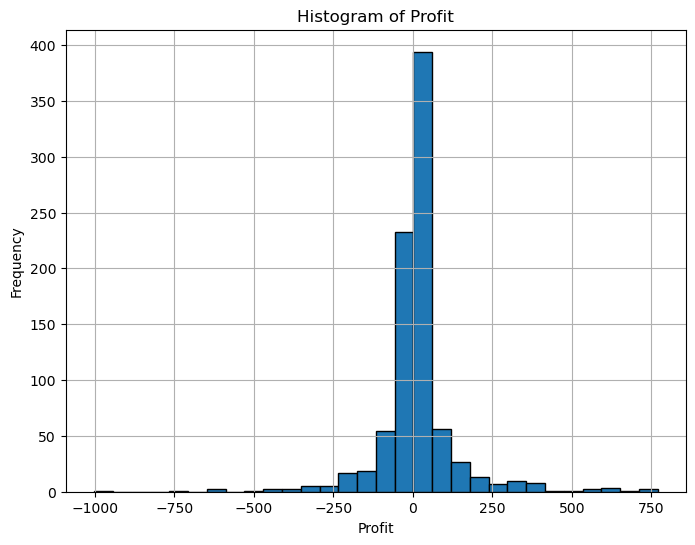

In [34]:
plt.figure(figsize=(8, 6))
modified_data['Profit'].hist(bins=30, edgecolor='black')
plt.title('Histogram of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

### One-Hot Encoding

In [52]:
modified_data = pd.get_dummies(modified_data, columns=['Ship Mode', 'Segment', 'Category', 'Sub-Category'], drop_first=True)

In [53]:
modified_data

,Sales,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,churn,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Sub-Category_Chairs,Sub-Category_Furnishings,Sub-Category_Tables
0,19.3000,5,0.60,-14.4750,0,97.0400,1.2130,316.092000,-42.551067,0,0,False,True,False,False,False,False,True,False
1,396.8020,7,0.30,-11.3372,360,19.3000,-14.4750,171.047333,-8.199733,12,0,False,True,False,False,False,True,False,False
2,258.0720,3,0.20,0.0000,0,620.6145,-248.2458,370.848833,-116.764600,0,1,False,False,True,False,True,False,True,False
3,177.2250,5,0.50,-120.5130,680,11.6880,-4.6752,202.864333,-160.638733,23,1,False,True,False,False,False,False,False,True
4,4.0440,3,0.60,-2.8308,680,177.2250,-120.5130,64.319000,-42.673000,23,1,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,383.4656,4,0.32,-67.6704,0,521.9600,88.7332,316.008533,12.558933,0,0,False,False,False,False,True,False,False,False
863,13.4000,1,0.00,6.4320,0,99.9500,22.9885,51.110000,12.871967,0,0,False,True,False,True,False,False,True,False
864,85.9800,1,0.00,22.3548,0,225.2960,22.5296,106.393333,15.686000,0,1,False,True,False,False,False,False,False,True
865,25.2480,3,0.20,4.1028,0,174.4200,41.8608,340.516000,86.550800,0,1,False,True,False,False,False,False,True,False


In [54]:
modified_data = modified_data.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

In [55]:
modified_data.head()

,Sales,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,churn,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Sub-Category_Chairs,Sub-Category_Furnishings,Sub-Category_Tables
0,19.300,5,0.6,-14.4750,0,97.0400,1.2130,316.092000,-42.551067,0,0,0,1,0,0,0,0,1,0
1,396.802,7,0.3,-11.3372,360,19.3000,-14.4750,171.047333,-8.199733,12,0,0,1,0,0,0,1,0,0
2,258.072,3,0.2,0.0000,0,620.6145,-248.2458,370.848833,-116.764600,0,1,0,0,1,0,1,0,1,0
3,177.225,5,0.5,-120.5130,680,11.6880,-4.6752,202.864333,-160.638733,23,1,0,1,0,0,0,0,0,1
4,4.044,3,0.6,-2.8308,680,177.2250,-120.5130,64.319000,-42.673000,23,1,0,1,0,0,0,0,1,0


### Standardize / Split Data
Why Standardize for Gaussian Naive Bayes?
Gaussian Naive Bayes Assumes Normal Distribution:
Gaussian Naive Bayes assumes that each feature is normally distributed within each class. While it doesn't require the data to be perfectly normal, it works better when the data is centered around the mean (0) with a spread (standard deviation) of 1. Standardization helps the data to better align with these assumptions.

Handling Features with Different Scales:
If you have features with vastly different ranges (e.g., Sales ranging from 100 to 10,000 and Quantity ranging from 1 to 100), they can dominate the model if not standardized. Standardizing ensures that each feature contributes equally to the model and prevents features with larger ranges from disproportionately affecting the results.

Distance-Based Assumptions:
Gaussian Naive Bayes calculates the likelihood of a feature under a Gaussian distribution for each class. Features that are on different scales can affect the likelihood estimation, so standardization makes these calculations more comparable across features.

In [56]:
X = modified_data.drop(columns=['churn'])

In [57]:
y = modified_data['churn']

In [58]:
#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [59]:
scaler = StandardScaler()

In [60]:
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

### Gaussian Naive Bayes Model

In [61]:
gnb = GaussianNB()

In [62]:
#Train
gnb.fit(X_train, y_train)

GaussianNB()

In [64]:
y_pred = gnb.predict(X_test)

### Evaluate

In [65]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.6015325670498084


In [68]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision}")

Precision: 0.6666666666666666


In [69]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall}")

Recall: 0.7393939393939394


In [70]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1}")

F1 Score: 0.7011494252873562
